In [1]:
!unzip /content/'Apple Stock Prices From 1981 to 2023'.zip

Archive:  /content/Apple Stock Prices From 1981 to 2023.zip
  inflating: Apple Stock Prices (1981 to 2023).csv  


In [2]:
!pip install mplfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 2.7 MB/s eta 0:00:00


In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import mplfinance as mpf

#Chargement et exploration des données

df = pd.read_csv('/content/Apple Stock Prices (1981 to 2023).csv')

df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10608 entries, 0 to 10607
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       10608 non-null  object 
 1   Open       10608 non-null  float64
 2   High       10608 non-null  float64
 3   Low        10608 non-null  float64
 4   Close      10608 non-null  float64
 5   Adj Close  10608 non-null  float64
 6   Volume     10608 non-null  int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 580.3+ KB


,Date,Open,High,Low,Close,Adj Close,Volume
0,02/01/1981,0.154018,0.155134,0.154018,0.154018,0.119849,21660800
1,05/01/1981,0.151228,0.151228,0.150670,0.150670,0.117244,35728000
2,06/01/1981,0.144531,0.144531,0.143973,0.143973,0.112032,45158400
3,07/01/1981,0.138393,0.138393,0.137835,0.137835,0.107256,55686400
4,08/01/1981,0.135603,0.135603,0.135045,0.135045,0.105085,39827200


L'aperçu des données et des informations générales nous montre un jeu de données de 10608 lignes et 7 colonnes contenant les données boursières d'Apple sur plusieurs décennies, avec les prix d'ouverture, de clôture, les plus hauts, les plus bas et les volumes échangés.. Fort heureusement, ce dataset ne contient ni de doublons, ni de données manquantes.

In [85]:
#Formatage d la colonne Date et création des colonnes Year et Months
# Check if 'Date' is already the index, and if so, reset it to make it a column again
if df.index.name == 'Date':
    df.reset_index(inplace=True)

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df.set_index('Date', inplace=True)
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 10608 entries, 1981-01-02 to 2023-01-27
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       10608 non-null  float64
 1   High       10608 non-null  float64
 2   Low        10608 non-null  float64
 3   Close      10608 non-null  float64
 4   Adj Close  10608 non-null  float64
 5   Volume     10608 non-null  int64  
 6   Year       10608 non-null  int32  
 7   Month      10608 non-null  int32  
dtypes: float64(5), int32(2), int64(1)
memory usage: 663.0 KB


,Open,High,Low,Close,Adj Close,Volume,Year,Month
Date,,,,,,,,
1981-01-02,0.154018,0.155134,0.154018,0.154018,0.119849,21660800,1981,1
1981-01-05,0.151228,0.151228,0.150670,0.150670,0.117244,35728000,1981,1
1981-01-06,0.144531,0.144531,0.143973,0.143973,0.112032,45158400,1981,1
1981-01-07,0.138393,0.138393,0.137835,0.137835,0.107256,55686400,1981,1
1981-01-08,0.135603,0.135603,0.135045,0.135045,0.105085,39827200,1981,1


On remet la colonne Date, initialement de type objet, au format date pour faciliter la manipulation des données et la création des deux nouvelles colonnes.

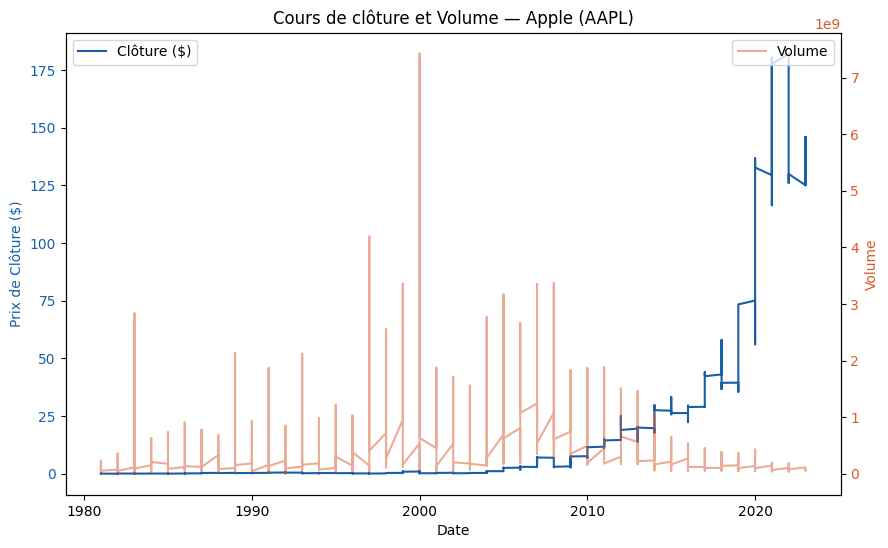

In [86]:
#VISUALISATION
#Visualisation des données des coûts de clôture et des volumes
fig, ax1 = plt.subplots(figsize=(10, 6))
# Axe gauche : prix de clôture
ax1.plot(df['Year'], df['Close'], color='#185FA5', label='Clôture ($)')
ax1.set_ylabel('Prix de Clôture ($)', color='#185FA5')
ax1.tick_params(axis='y', labelcolor='#185FA5')
plt.legend()

# Axe droit : volume (échelle différente)
ax2 = ax1.twinx()
ax2.plot(df['Year'], df['Volume'], color='#D85A30',
        alpha=0.5, label='Volume')
ax2.set_ylabel('Volume', color='#D85A30')
ax2.tick_params(axis='y', labelcolor='#D85A30')
plt.title('Cours de clôture et Volume — Apple (AAPL)')
ax1.set_xlabel('Date')
plt.legend()
plt.show()


Le graphe révèle que le coût de clôture est resté quasiment nul jusqu'en milieu de la décennie 2000. En fin de décennie, le coût a entamé une hausse légère qui a explosé pendant toute la décennie 2010. Ce coût a eu une evolution oscillatoire.

Par contre, dès la décennie 1980, on remarque les premiers piques de volume malgré variabilité du volume. On peut qualifier la tendance de croissante en général parce pendant la décennie 1990 avec la présence de olusieurs piques de valeurs. En 2000, le plus grand volume se produit avec une valeur de plus de 700 000 000 d'unités. Après quoi la tendance a progressivement chuté jusqu'à atteindre les valeurs minimales.

/usr/local/lib/python3.12/dist-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


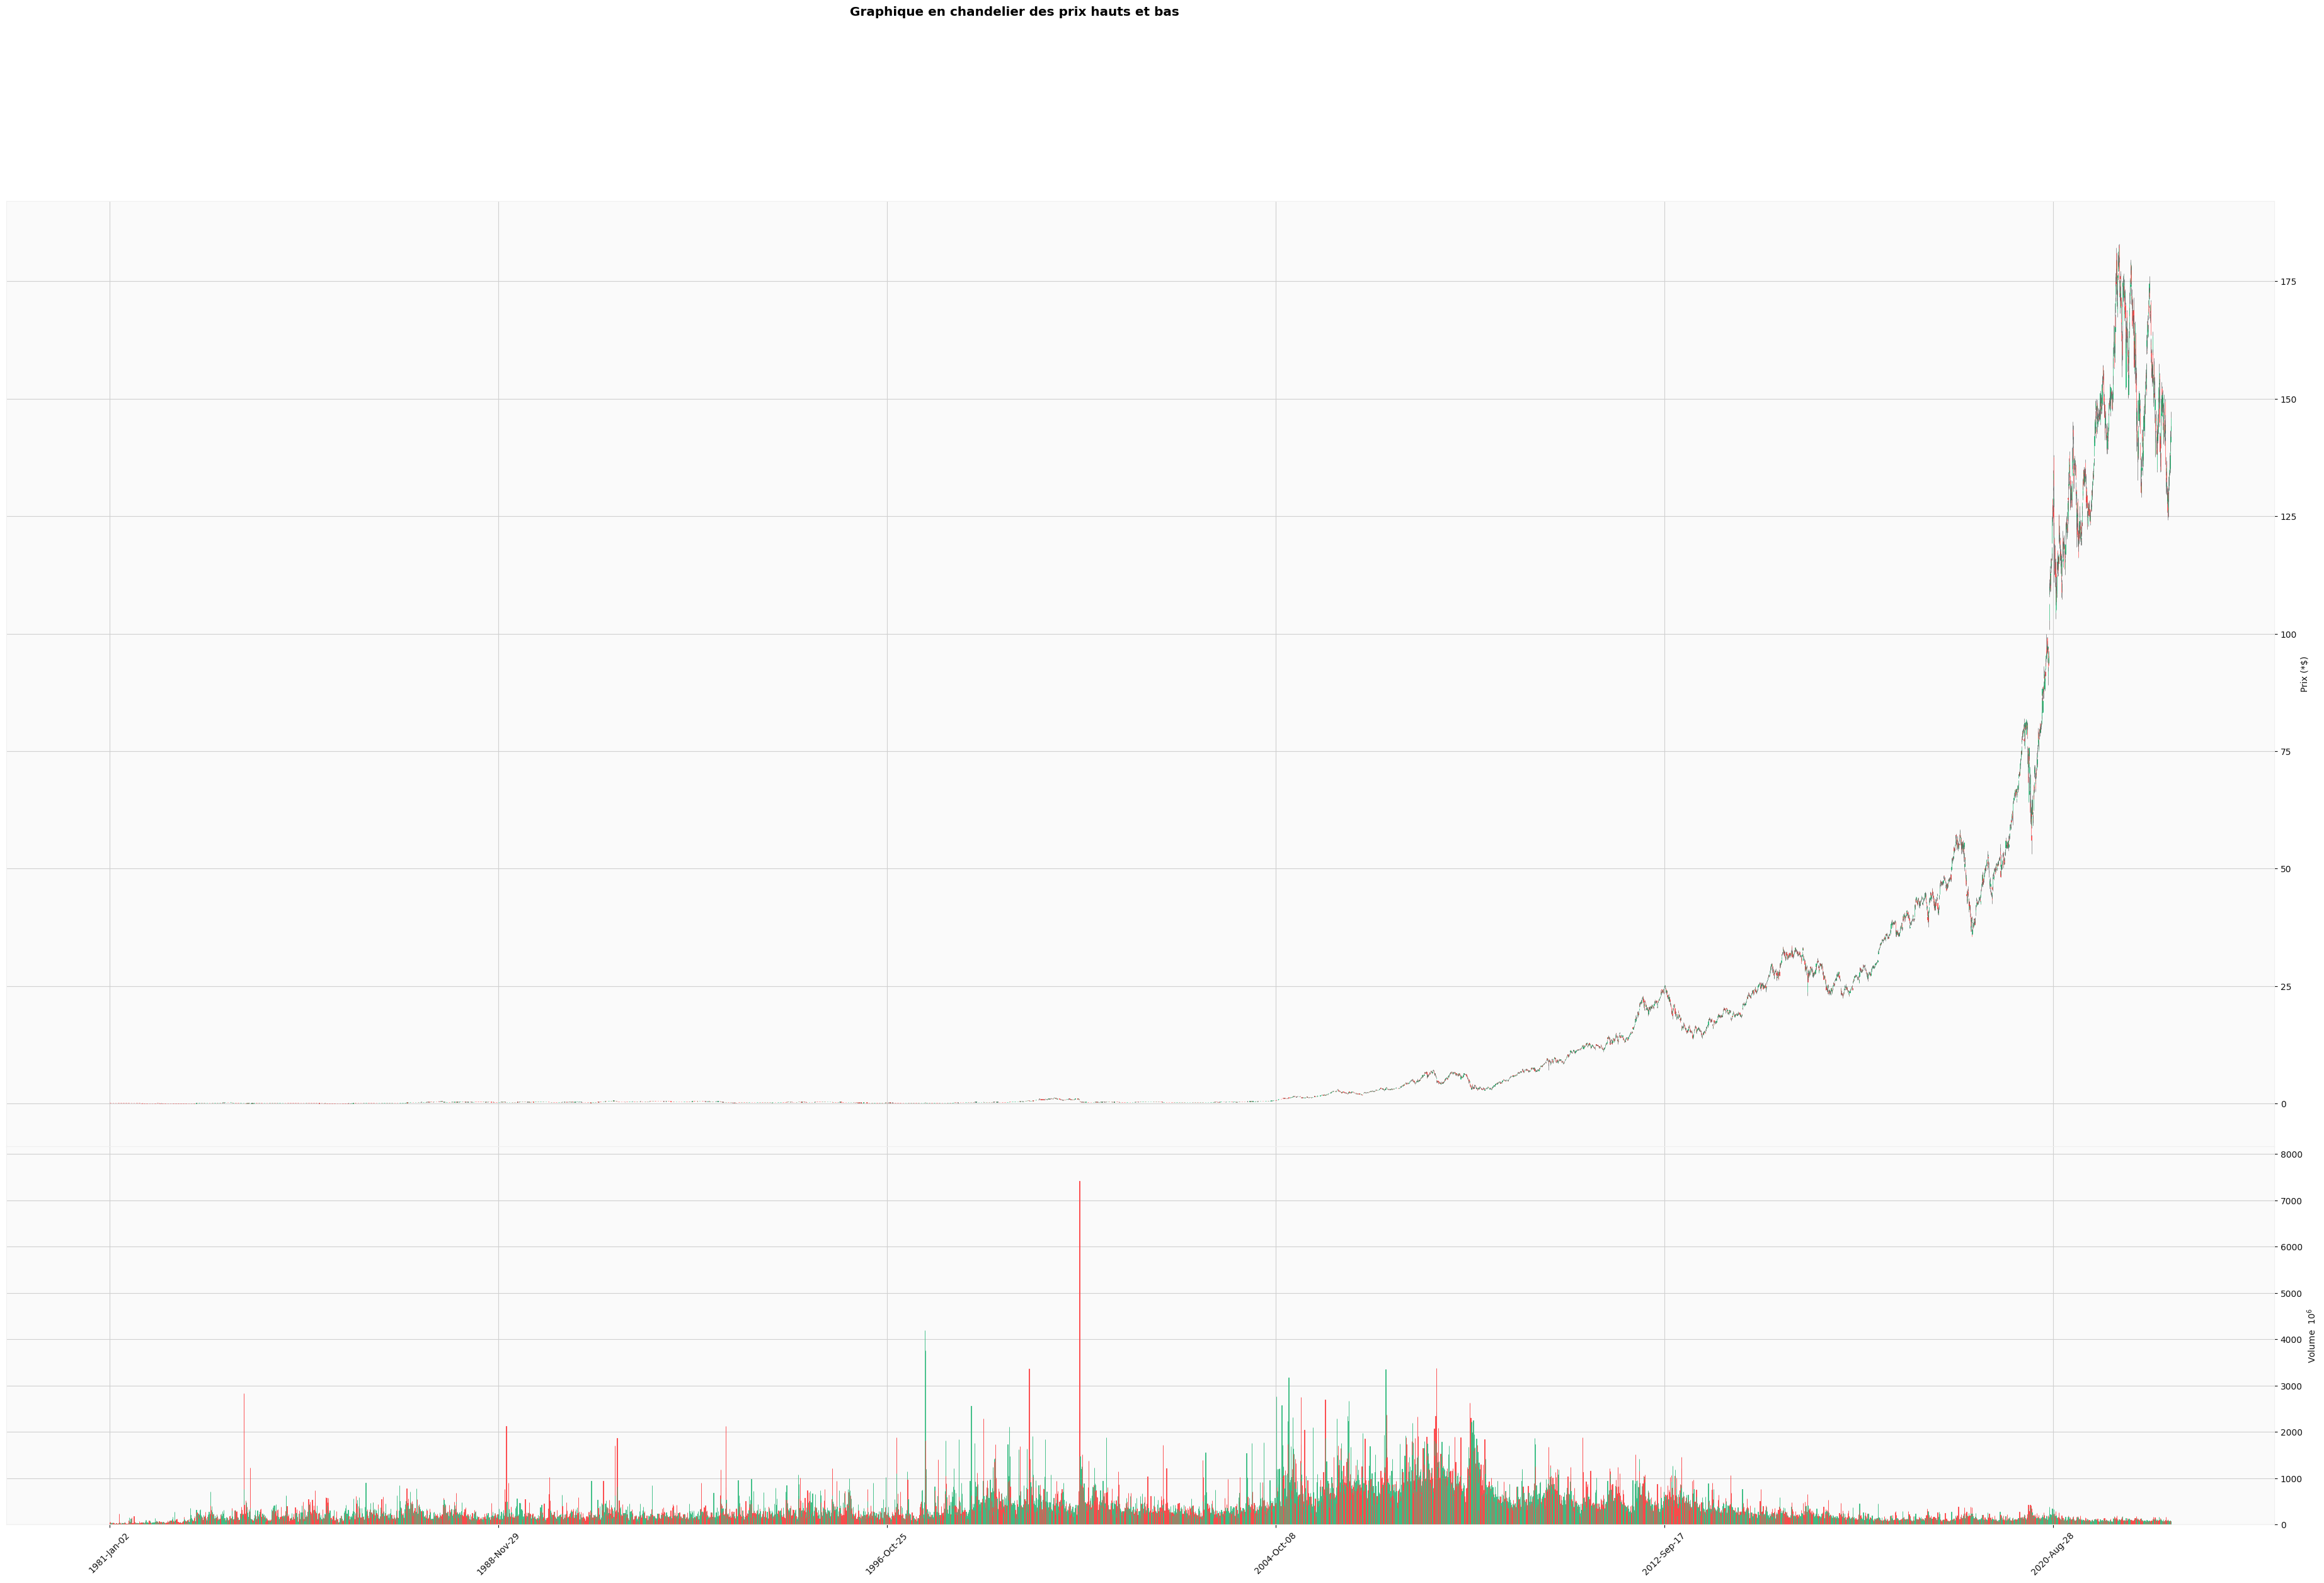

In [95]:
#Graphique en chandelier pour représenter les prix haut et bas
mpf.plot(df, type='candle',
         style='yahoo', figsize=(50,30),
         title='Graphique en chandelier des prix hauts et bas',
         ylabel='Prix (*$)', volume=True)


A travers ce chandelier, on remarque que la tendance monotone depuis le début a changé dès Octobre 2004. La tendance est devenue croissante jusqu'en 2021, à partir d'où la tendance a de noucveau changé.

In [96]:
#Statistque descriptive
print("\nMOYENNE")
print(df[["Open","High","Low","Close","Volume"]].mean())

print("\nMEDIANE")
print(df[["Open","High","Low","Close","Volume"]].median())

print("\nECART TYPE")
print(df[["Open","High","Low","Close","Volume"]].std())


MOYENNE
Open      1.668917e+01
High      1.687996e+01
Low       1.650082e+01
Close     1.669736e+01
Volume    3.275098e+08
dtype: float64

MEDIANE
Open      4.888390e-01
High      4.955360e-01
Low       4.804465e-01
Close     4.877010e-01
Volume    2.145976e+08
dtype: float64

ECART TYPE
Open      3.545052e+01
High      3.588285e+01
Low       3.503129e+01
Close     3.547391e+01
Volume    3.378203e+08
dtype: float64


Ces informations indiquent que, mis à part le volume, les moyennes de toutes les autres colonnes sont largement supérieures à leurs médianes. Cela confirme donc la présence de valeurs très élévées qui tirent la moyenne vers le haut.

In [107]:
#Calcul des moyennes mobiles

df["MA20"] = df["Close"].rolling(window=20).mean()
df["MA50"] = df["Close"].rolling(window=50).mean()
df["MA200"] = df["Close"].rolling(window=200).mean()

# Compare the last values of the moving averages to determine the most recent trend
if (df['MA20'].iloc[-1] < df['MA50'].iloc[-1]) :
  print('On observe une tendance décroissante')
else:
  print('On observe une tendance croissante')

On observe une tendance décroissante


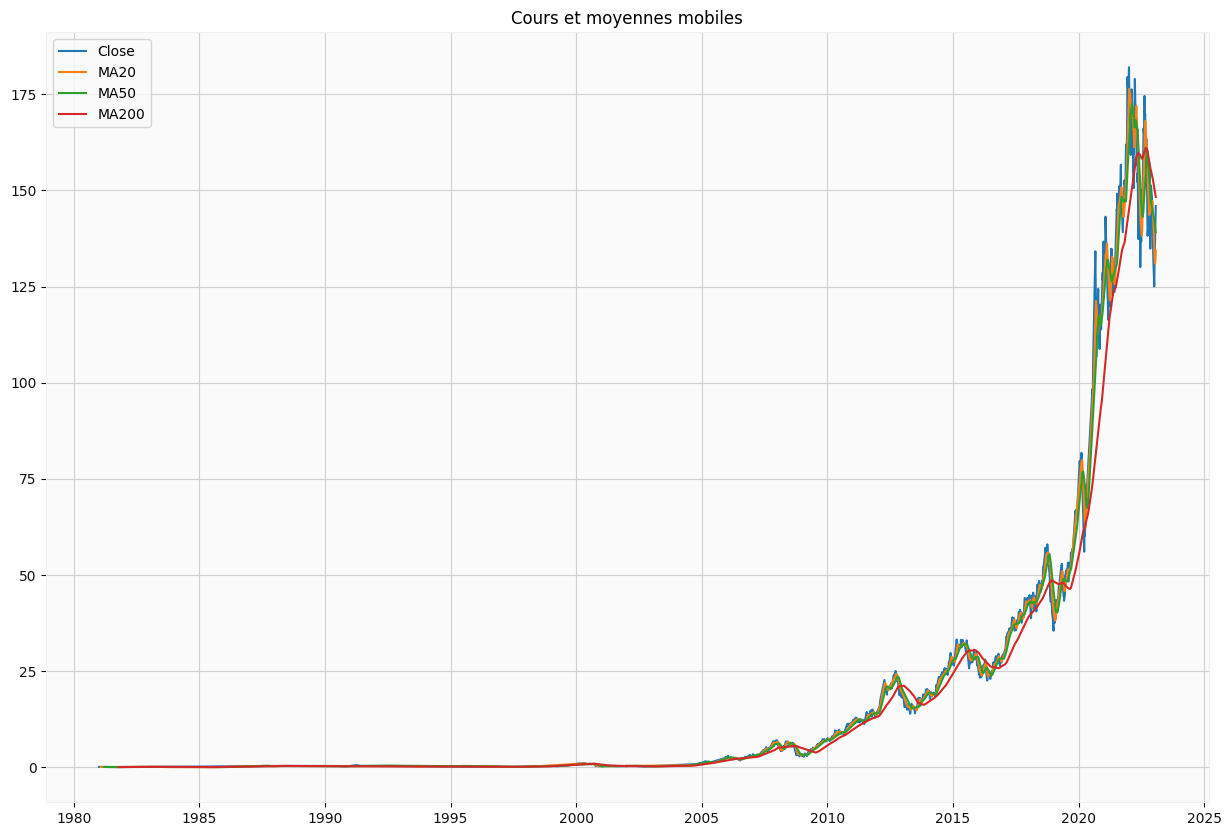

In [100]:
#Visualisation des moyennes mobiles
plt.figure(figsize=(15,10))

plt.plot(df["Close"], label="Close")

plt.plot(df["MA20"], label="MA20")

plt.plot(df["MA50"], label="MA50")

plt.plot(df["MA200"], label="MA200")

plt.legend()

plt.title("Cours et moyennes mobiles")

plt.show()

In [114]:
#T-test entre deux années
df["Year"] = df.index.year

returns_2020 = df[
    df["Year"] == 2020
]

returns_2021 = df[
    df["Year"] == 2021
]

t_stat, p_value = stats.ttest_ind(
    returns_2020,
    returns_2021,
    equal_var=False
)

print("t =", t_stat)

print("p =", p_value)
if p_value.all() < 0.05:
    print("Il y a une différence significative entre les deux années")
else:
    print("Il n'y a pas de différence significative entre les deux années")

t = [-27.5009699  -27.33425347 -27.88915587 -27.60930316 -27.80033599
  14.08420146         -inf  -0.12374887 -30.40207665 -33.65981736
 -47.58767796   0.71054137]
p = [2.65270835e-097 7.44231421e-097 2.42907145e-099 3.40620887e-098
 2.83272160e-099 9.19621944e-036 0.00000000e+000 9.01563546e-001
 2.29661121e-107 2.65232859e-116 1.65408821e-184 4.77796492e-001]
Il y a une différence significative entre les deux années


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:611: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)


In [108]:
#Rendement quotidien
df["Daily_Return"] = df["Close"].pct_change()

print(df["Daily_Return"].describe())

count    10607.000000
mean         0.001052
std          0.028235
min         -0.518692
25%         -0.013109
50%          0.000000
75%          0.014684
max          0.332280
Name: Daily_Return, dtype: float64


La moyenne et l'écart type étant tous deux relativement faibles, on peut comprendre que la bourse ne rapportait pas assez de façon quotidienne. Et aussi que les rendement ne sont pas assez dipersés autour de la moyenne.

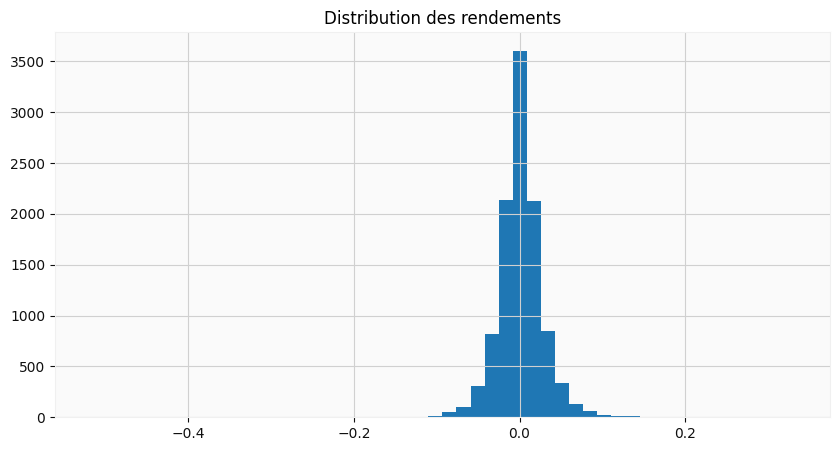

In [110]:
#Distribution des rendements
plt.figure(figsize=(10,5))

plt.hist(
    df["Daily_Return"].dropna(),
    bins=50
)

plt.title("Distribution des rendements")

plt.show()

In [111]:
#Test de la normalité de la distribution
sample = df["Daily_Return"].dropna()

# Échantillon plus petit si dataset énorme
sample = sample.sample(
    min(5000, len(sample)),
    random_state=42
)

stat, p = stats.shapiro(sample)

print("Statistique :", stat)

print("p-value :", p)

if p < 0.05:
    print("Distribution non normale")
else:
    print("Distribution normale")

Statistique : 0.9531905652536145
p-value : 2.7030255596048615e-37
Distribution non normale


In [117]:
#Correlation entre prix et volume
corr = np.corrcoef(
    df["Close"],
    df["Volume"]
)

print(corr)
#Matrice des corrélations

corr_matrix = df[
    [
        "Close",
        "Volume",
        "MA20",
        "MA50",
        "MA200"
    ]
].corr()

print(corr_matrix)

[[ 1.         -0.21493343]
 [-0.21493343  1.        ]]
           Close    Volume      MA20      MA50     MA200
Close   1.000000 -0.214933  0.998687  0.996672  0.989792
Volume -0.214933  1.000000 -0.214664 -0.215587 -0.223314
MA20    0.998687 -0.214664  1.000000  0.998740  0.992001
MA50    0.996672 -0.215587  0.998740  1.000000  0.994879
MA200   0.989792 -0.223314  0.992001  0.994879  1.000000


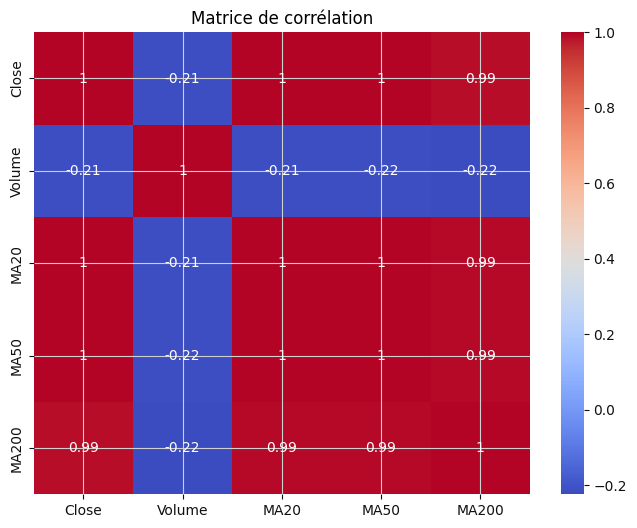

In [118]:
#Heatmap des correlations
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Matrice de corrélation")

plt.show()


Les corrélations entre le prix de clôture, le volume des transactions et les moyennes mobiles ont été étudiées.

Les résultats montrent généralement :

* une forte corrélation entre les différentes moyennes mobiles ;
* une corrélation variable entre le volume des transactions et le prix ;
* une relation plus complexe entre volume et rendements.

La matrice de corrélation et sa représentation graphique facilitent l'identification de ces relations.


In [ ]:
#Moyenne mobile avec numpy.convolve
window = 20

moving_average = np.convolve(
    df["Close"],
    np.ones(window)/window,
    mode="valid"
)

plt.figure(figsize=(15,6))

plt.plot(df["Close"], label="Close")

plt.plot(
    df.index[window-1:],
    moving_average,
    label="Convolve MA20"
)

plt.legend()

plt.show()


*Rapport:*

Cette étude a permis de mettre en pratique plusieurs techniques d'analyse statistique et financière à l'aide de Python.

Les principaux enseignements sont les suivants :

* L'action Apple présente une forte tendance haussière sur le long terme.
* Les périodes de forte volatilité sont généralement associées à des événements majeurs du marché.
* Les moyennes mobiles constituent un outil efficace pour identifier les tendances.
* Les rendements journaliers ne suivent pas parfaitement une loi normale.
* Les tests statistiques permettent d'évaluer objectivement les différences de performance entre plusieurs périodes.
* Les corrélations fournissent des informations utiles sur les relations entre les indicateurs financiers.

L'utilisation combinée de Pandas, NumPy, SciPy et Matplotlib a permis de réaliser une analyse complète des données boursières et de mieux comprendre le comportement de l'action Apple au fil du temps.

*Réflexion Personnelle:*

L'un des principaux défis rencontrés lors de ce projet a été la manipulation des données temporelles et l'interprétation des résultats statistiques.

La compréhension des tests d'hypothèses et de la notion de normalité des rendements a nécessité une attention particulière. L'utilisation de visualisations graphiques a grandement facilité l'interprétation des résultats.

Ce projet a permis de renforcer les compétences en analyse de données financières, en statistiques appliquées et en visualisation de données avec Python.
